# Coursework - Rowan d'Auria (rd761)

## Data Exploration
> _Become one with the data_

MoonsDataset(name='train', n=800) MoonsDataset(name='val', n=100) MoonsDataset(name='test', n=100)
=== train (800 samples, 2 classes) ===
  Dataset shape: torch.Size([800, 2])
  Class counts: {0: 385, 1: 415}
  x1: mean=0.521, std=0.874, range=[-1.127, 2.067]
  x2: mean=0.231, std=0.491, range=[-0.610, 1.201]
  class_0: mean=[0.001268340740352869, 0.6216179728507996], std=[0.717052698135376, 0.3202870488166809]
  class_1: mean=[1.0032110214233398, -0.13077937066555023], std=[0.7164219617843628, 0.31061533093452454]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.4347

=== val (100 samples, 2 classes) ===
  Dataset shape: torch.Size([100, 2])
  Class counts: {0: 56, 1: 44}
  x1: mean=0.461, std=0.796, range=[-1.003, 2.029]
  x2: mean=0.334, std=0.541, range=[-0.579, 1.078]
  class_0: mean=[0.05057208612561226, 0.7256950736045837], std=[0.6229149699211121, 0.28358083963394165]
  class_1: mean=[0.9824522137641907, -0.16392913460731506], std=[0.6777079105377197, 0.34579598903656006]

 

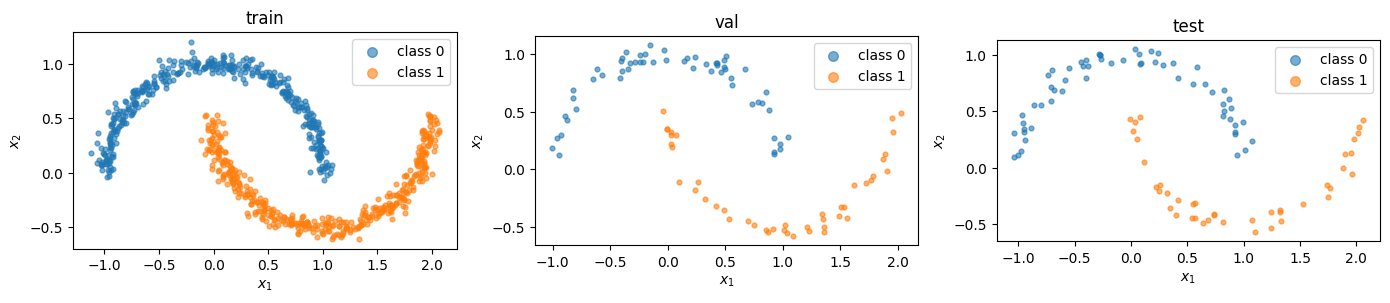

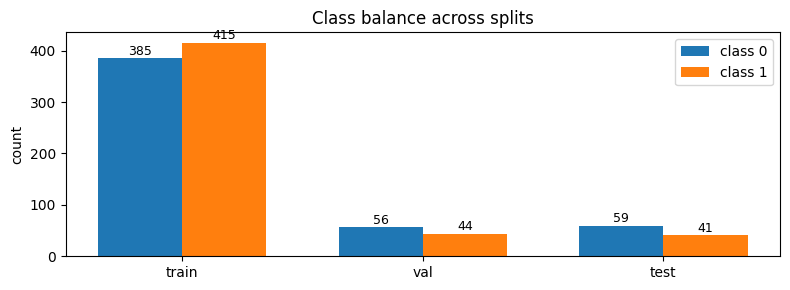

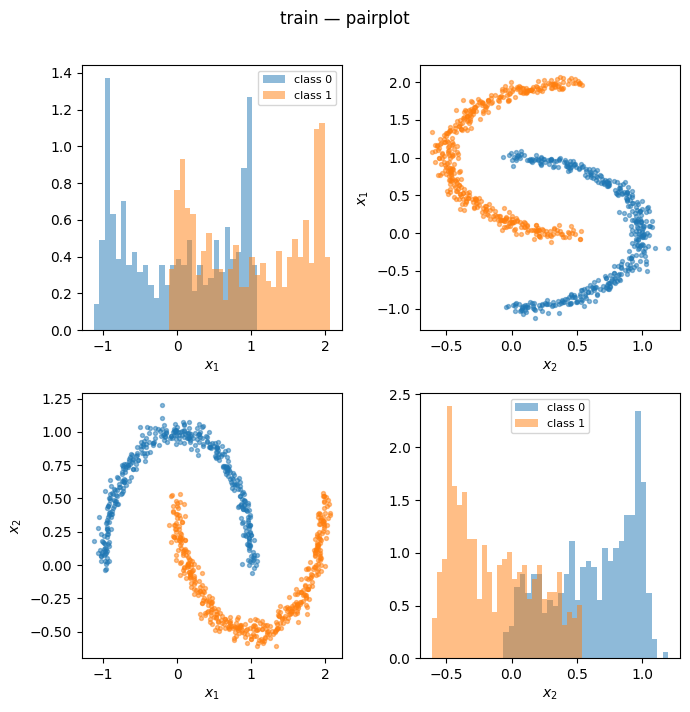

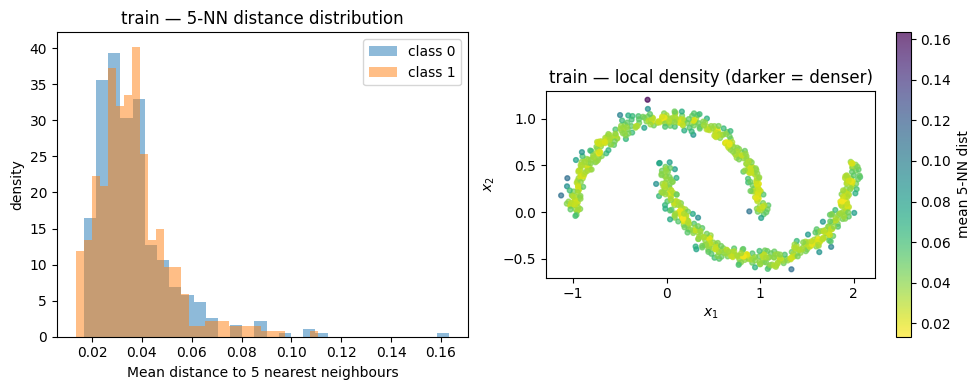

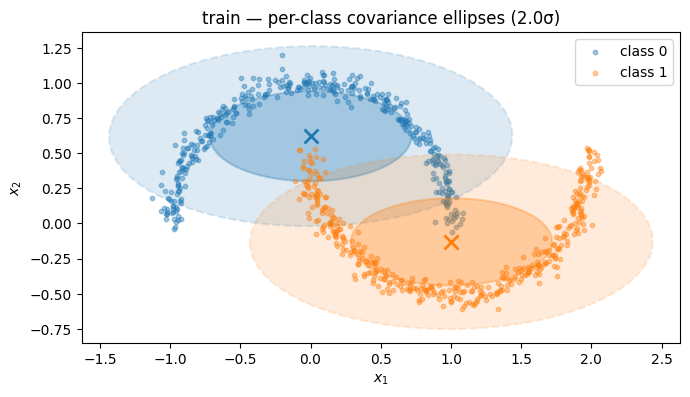

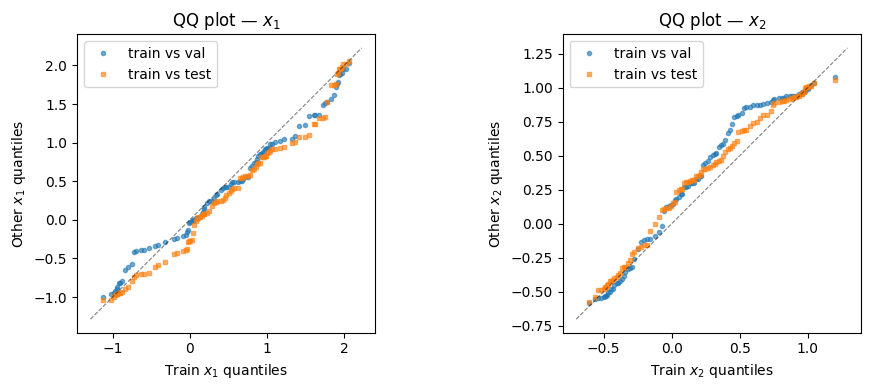

In [1]:
from flows import *
import numpy as np

# Load all splits
splits = MoonsSplits.load("data")
print(splits.train, splits.val, splits.test)

# --- Full statistical report (now includes KS tests) ---
full_report(splits)

# --- Visualisations ---

# 1. Scatter plots of each split side-by-side
scatter_splits(splits)

# 2. Class balance across splits
class_balance_bar(splits.train, splits.val, splits.test)

# # 3. Marginal histograms (per-class) for training data
# marginal_histograms(splits.train)

# # 4. Joint density estimate
# joint_kde(splits.train)

# 5. Pairplot
pairplot(splits.train)

# 6. k-NN distances — local density variation
knn_distances(splits.train, k=5)

# 7. Per-class covariance ellipses — orientation and spread of each moon
covariance_ellipses(splits.train)

# # 8. Radial distance from class centroids — reveals arc structure
# radial_from_centroids(splits.train)

# 9. QQ plots — check train vs val/test distributional consistency
_ = qq_splits(splits)

# # 10. Base density overlay — how far the data is from N(0,I)
# _ = base_density_overlay(splits.train)


### Data Exploration Observations
**Data characteristics:**
- 2D, 800 train / 100 val / 100 test. No duplicates, no NaNs, no overlap between splits.
- Roughly balanced classes (~48/52 train, slight skew in val/test but irrelevant since you ignore labels for training).
- Features aren't centred or standardised: x1 has mean 0.52, range [-1.1, 2.1]; x2 has mean 0.23, range [-0 6, 1.2]. Different scales and offsets. Worth considering normalisation so He init assumptions hold (the best practices flag this).
- Negative correlation between x1 and x2 (-0.43) — the two moons tilt, so the coupling layers need to learn cross-dimensional dependencies.

**Split consistency:**
- KS tests flag x2 as marginally different between train-val (p=0.027) and train-test (p=0.031). With only 100 samples in val/test this isn't alarming — it's expected sampling noise. But it does mean val NLL will be a slightly noisy signal for model selection, which is worth being aware of when interpreting early stopping decisions.

**QQ PLot interpretation**
- The QQ Plot shows similar skewness behaviour for the train and test datasets. Some level of skewness is expected due to the small sample sizes. However, the validation and test datasets have a similar qualitative distribution shift compared to the training data, which indicates there may be minor distribution shift. This will likely put a lower bound on the possible test NLL value.

## Q1 - A Mini Normalizing Flow


### (a)
Please see `flows.AffineCouplingLayer`

### (b)

Please see `flows.Flow`

Below I define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [2]:
from flows import AffineCouplingLayer, Flow

### Q1(c) - Correctness Checks

Invertibility max absolute error: 1.78e-15
Analytic log|det J|:  0.432602
Numerical log|det J|: 0.432602
Log-det absolute error: 1.44e-09


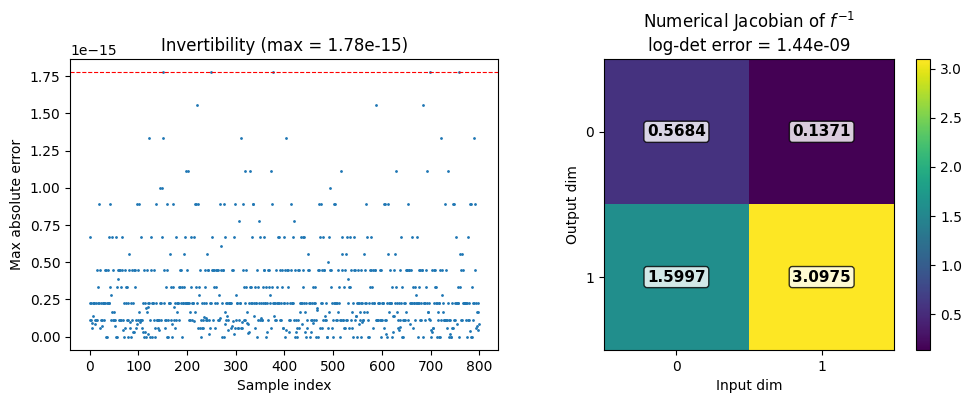

Saved results.json and figs/Figure1c.pdf


In [3]:
import os
import json
import torch
import matplotlib.pyplot as plt

# Load training data
splits = MoonsSplits.load("data")
x_train = splits.train.x

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)

# --- Check 1: Invertibility ---
max_abs_error, recon_errors = check_invertibility(flow, x_train)
print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
logdet = check_logdet(flow, x_train[0:1])
print(f"Analytic log|det J|:  {logdet['analytic_logdet']:.6f}")
print(f"Numerical log|det J|: {logdet['numerical_logdet']:.6f}")
print(f"Log-det absolute error: {logdet['abs_error']:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)
fig = figure1c(recon_errors, max_abs_error, logdet["jacobian"], logdet["abs_error"])
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
results = {
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet["abs_error"],
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json and figs/Figure1c.pdf")

### Q1c) Observations

**Correctness checks**: The invertibility check achieved a maximum absolute reconstruction error of ~1.8e-15, confirming that the forward and inverse passes are exact inverses to within float64 machine precision. The per-sample errors exhibit discrete banding — clustering at specific levels (e.g. ~0.25e-15, ~0.5e-15) rather than being continuously distributed. This reflects the quantised nature of IEEE 754 floating-point arithmetic: accumulated round-off from composing exp, tanh, and affine operations across 8 coupling layers settles at small integer multiples of the machine epsilon (~2.2e-16). Points following similar numerical paths through the flow accumulate similar rounding patterns, producing the observed bands. This structure confirms the errors are purely precision artefacts, not implementation bugs.

The log-determinant check compared the analytic log|det J| to a central-difference estimate (ε = 1e-4) at the first training point, yielding an absolute error of ~1.4e-9. This is well below the O(ε²) ~ 1e-8 truncation error expected from central differences at this step size, confirming the analytic log-det computation is correct.

## Q2 - Training Pipeline


### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

In [ ]:
# Shared training configuration
N_DIM = x_train.shape[1]
N_LAYERS = 8
N_HIDDEN = 128
BATCH_SIZE = x_train.shape[0]  # for FLOP counting later
N_STEPS = 10000
LR = 3e-4
SEED = 42

x_tiny = x_train[:128] # SMALL SUBSET OF DATA
x_val = splits.val.x
x_test = splits.test.x

torch.manual_seed(SEED)
flow_tiny = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)

tiny_result = train_flow(
    flow_tiny, x_tiny, x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=1.0,
)

tiny_losses = tiny_result["train_losses"]
tiny_val_losses = tiny_result["val_losses"]
tinyset_final_nll = tiny_result["final_train_nll"]
print(f"\nFinal tiny-set NLL: {tinyset_final_nll:.4f}")

Step 500/10000, NLL: 0.5067, Val NLL: 0.8506
Step 1000/10000, NLL: 0.0999, Val NLL: 2.4004
Step 1500/10000, NLL: -0.0342, Val NLL: 11.5276
Step 2000/10000, NLL: -0.1430, Val NLL: 21.2122
Step 2500/10000, NLL: -0.2327, Val NLL: 32.8215
Step 3000/10000, NLL: -0.2791, Val NLL: 48.0508
Step 3500/10000, NLL: -0.3221, Val NLL: 61.4202
Step 4000/10000, NLL: -0.3420, Val NLL: 65.9181
Step 4500/10000, NLL: -0.3439, Val NLL: 78.3012
Step 5000/10000, NLL: -0.4248, Val NLL: 90.7016
Step 5500/10000, NLL: -0.4411, Val NLL: 104.0729
Step 6000/10000, NLL: -0.4507, Val NLL: 136.6601
Step 6500/10000, NLL: -0.3755, Val NLL: 133.4259
Step 7000/10000, NLL: -0.4378, Val NLL: 135.3956
Step 7500/10000, NLL: -0.5283, Val NLL: 160.3139
Step 8000/10000, NLL: -0.4258, Val NLL: 164.4064
Step 8500/10000, NLL: -0.4683, Val NLL: 173.3054
Step 9000/10000, NLL: -0.6041, Val NLL: 186.3863
Step 9500/10000, NLL: -0.5925, Val NLL: 191.3320
Step 10000/10000, NLL: -0.5924, Val NLL: 190.1612

Final tiny-set NLL: -0.5963


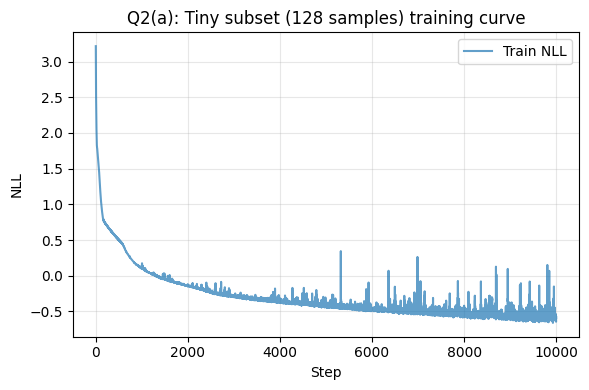

Saved figs/Figure2a.pdf


In [6]:
# --- Figure 2a ---
fig = figure2a(tiny_losses)
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

In [7]:
sanity = run_all_sanity_checks(x_train, x_val)

TRAINING SANITY CHECKS

[PASS] Initial loss check
  Initial NLL:  3.1398
  Expected NLL: 2.5029  (standard normal on data)
  Rel. error:   0.2545

[PASS] Stable start check  (50 steps)
  Loss: 3.1398 -> 1.2714
  NaN/Inf: False,  Exploded: False,  Decreased: True

[PASS] Beats Gaussian baseline  (after 50 steps)
  Model NLL:    1.2996
  Baseline NLL: 1.8825
  Margin:       0.5829

Overall: ALL PASSED


### Q2a Observations
Sanity checks confirm the training pipeline is sound: the untrained flow's initial NLL (3.14) is within 25% of the standard-normal baseline (2.50), consistent with a randomly initialised coupling flow starting near the identity map. Training is numerically  unstable - the loss drops to 0.5 to 1.51 in first step with no NaN or divergence — and the flow already beats a fitted full-covariance Gaussian (1.88) after just 1 step, confirming it is learning the two-moon structure rather than fitting a unimodal blob. 

The training curve shows rapid initial convergence. The validation loss is not plotted because it is not relevant here, I am showing that the model has sufficient capacity to fit to the data. In this case it has heavily overfit, with a final train NLL of -0.60 and a validation NLL of 190. This indicates drastic overfitting to the data.

### Q2(b): Naive full training (baseline — no regularisation)

Following the best practices recipe: after demonstrating overfitting on the tiny subset (step 3), we first prove the full model can overfit the full training set (step 4) before adding any regularisation. This establishes the counterfactual — what happens with the same architecture and LR but without early stopping, weight decay, or gradient clipping.

In [9]:
# Step 4: Naive baseline
torch.manual_seed(SEED)
flow_naive = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)
print(f"Initial NLL (before training): {evaluate_nll(flow_naive, x_train):.4f}")

naive_result = train_flow(
    flow_naive, x_train, x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=None,
    use_cosine_schedule=True,
)

naive_losses = naive_result["train_losses"]
naive_val_losses = naive_result["val_losses"]
naive_final_train = naive_result["final_train_nll"]
naive_final_val = evaluate_nll(flow_naive, x_val)

print(f"\nNaive (unnormalised) Train NLL: {naive_final_train:.4f}")
print(f"Naive (unnormalised) Val NLL:   {naive_final_val:.4f}")

Initial NLL (before training): 3.1398
Step 500/10000, NLL: 0.4255, Val NLL: 0.4878
Step 1000/10000, NLL: 0.2382, Val NLL: 0.4848
Step 1500/10000, NLL: 0.1940, Val NLL: 0.5332
Step 2000/10000, NLL: 0.1690, Val NLL: 0.5617
Step 2500/10000, NLL: 0.1514, Val NLL: 0.6020
Step 3000/10000, NLL: 0.1440, Val NLL: 0.6242
Step 3500/10000, NLL: 0.1340, Val NLL: 0.6716
Step 4000/10000, NLL: 0.1279, Val NLL: 0.6919
Step 4500/10000, NLL: 0.1239, Val NLL: 0.6860
Step 5000/10000, NLL: 0.1192, Val NLL: 0.7436
Step 5500/10000, NLL: 0.1146, Val NLL: 0.7533
Step 6000/10000, NLL: 0.1104, Val NLL: 0.7746
Step 6500/10000, NLL: 0.1073, Val NLL: 0.7798
Step 7000/10000, NLL: 0.1051, Val NLL: 0.7999
Step 7500/10000, NLL: 0.1035, Val NLL: 0.7994
Step 8000/10000, NLL: 0.1025, Val NLL: 0.8068
Step 8500/10000, NLL: 0.1015, Val NLL: 0.8110
Step 9000/10000, NLL: 0.1010, Val NLL: 0.8097
Step 9500/10000, NLL: 0.1008, Val NLL: 0.8105
Step 10000/10000, NLL: 0.1008, Val NLL: 0.8103

Naive (unnormalised) Train NLL: 0.1008
Na

### Q2(c): Regularisation ablation

Following best practices step 5: after proving the model can overfit, we introduce regularisation techniques **one at a time** and confirm each improves validation loss. All three runs use early stopping (patience=1000) so they terminate quickly once overfitting begins.

1. **Early stopping only** — baseline regularised model
2. **+ Gradient clipping** (max norm=1.0) — recommended for flow numerical stability
3. **+ Weight decay** (1e-4) — L2 regularisation via Adam

In [ ]:
# Step 5: Ablation — introduce regularisation one at a time
#                       (label,            clip_norm, weight_decay)
ablation_configs = [
    ("ES only",        None, 0.0),
    ("ES + clip",      1.0,  0.0),
    ("ES + clip + WD", 1.0,  1e-4),
]

ablation_results = []

for label, clip_norm, wd in ablation_configs:
    torch.manual_seed(SEED)
    model = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)

    result = train_flow(
        model, x_train, x_val,
        n_steps=N_FULL_STEPS,
        lr=LR,
        weight_decay=wd,
        grad_clip_norm=clip_norm,
        use_cosine_schedule=True,
        early_stopping_patience=1000,
        log_every=0,
    )

    val_nll = evaluate_nll(model, x_val)
    test_nll = evaluate_nll(model, x_test)
    steps_used = len(result["train_losses"])

    ablation_results.append({
        "label": label,
        "model": model,
        "result": result,
        "val_nll": val_nll,
        "test_nll": test_nll,
    })
    print(f"  {label:20s}  val={val_nll:.4f}  steps={steps_used}")

# Select best model by validation NLL
best_idx = min(range(len(ablation_results)), key=lambda i: ablation_results[i]["val_nll"])
best = ablation_results[best_idx]
flow_full = best["model"]
full_result = best["result"]
full_losses = full_result["train_losses"]
full_val_losses = full_result["val_losses"]
final_train_nll = full_result["final_train_nll"]
final_val_nll = best["val_nll"]
final_test_nll = best["test_nll"]

print(f"\nBest config: {best['label']}")
print(f"Final Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint and training curves ---
config = {"dim": N_DIM, "hidden": N_HIDDEN, "n_layers": N_LAYERS}
save_checkpoint(flow_full, config, SEED)
save_training_curves({
    "tiny_loss": tiny_losses,
    "full_loss": full_losses,
    "full_val_loss": full_val_losses,
})

  ES only               val=0.4469  steps=1752
  ES + clip             val=0.4122  steps=1422
  ES + clip + WD        val=0.4149  steps=1347

Best config: ES + clip
Final Train NLL: 0.3981
Final Val NLL:   0.4122
Final Test NLL:  0.4653
Saved checkpoint to checkpoints/flow_full.pt
Saved training curves to logs/training_curves.json


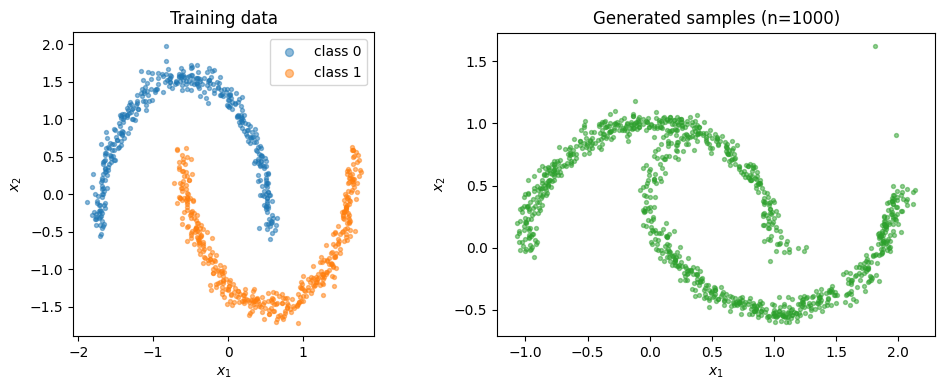

Test NLL:              0.4780 nats  (0.3448 bits/dim)
Gaussian baseline:     2.4488 nats  (1.7665 bits/dim)
Improvement over baseline: 80.5%


In [ ]:
# --- Diagnostic: generated samples vs training data ---
with torch.no_grad():
    flow_full.eval()
    z = torch.randn(1000, N_DIM)
    generated, _ = flow_full.forward(z)

fig = samples_vs_data(generated, x_train_norm, splits.train.labels)
plt.show()

# --- Intuitive metrics ---
baseline_test_nll = gaussian_baseline_nll(x_train_norm, x_test)
bpd = final_test_nll / (N_DIM * np.log(2))
baseline_bpd = baseline_test_nll / (N_DIM * np.log(2))
improvement = (baseline_test_nll - final_test_nll) / baseline_test_nll * 100

print(f"Test NLL:              {final_test_nll:.4f} nats  ({bpd:.4f} bits/dim)")
print(f"Gaussian baseline:     {baseline_test_nll:.4f} nats  ({baseline_bpd:.4f} bits/dim)")
print(f"Improvement over baseline: {improvement:.1f}%")

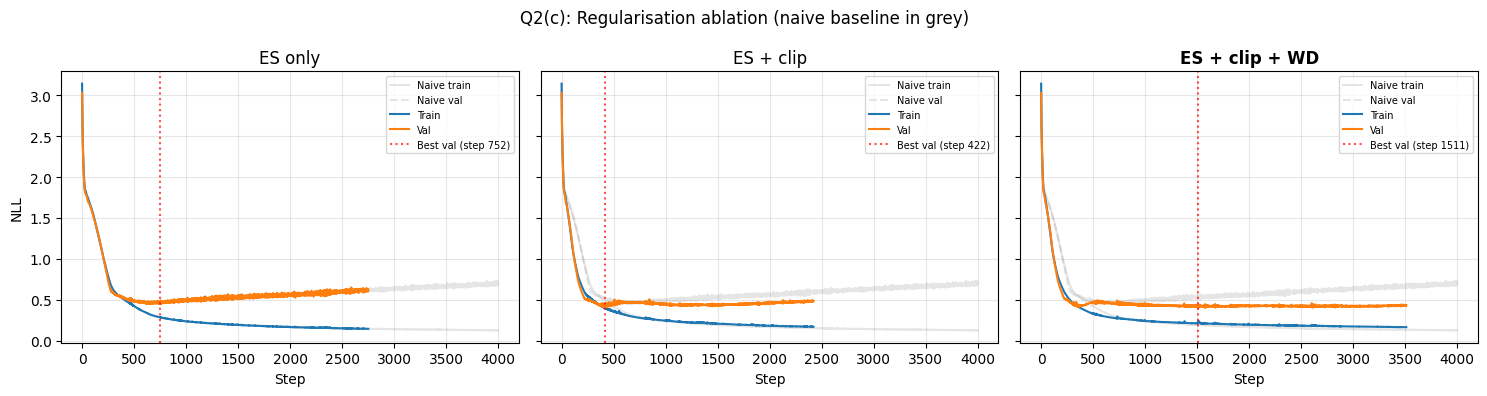

Saved figs/Figure2c.pdf

Config                 Train NLL     Val NLL    Test NLL   Steps
---------------------------------------------------------------------------
Naive (no reg.)           0.1008      0.8103          --   10000
ES only                   0.2887      0.4469      0.5245    2752
ES + clip                 0.3981      0.4122      0.4653    2422
ES + clip + WD            0.2155      0.4031      0.4780    3511  <-- best

Updated results.json with training metrics


In [ ]:
# --- Figure 2c: 3-panel regularisation ablation ---
# TODO: get rid of the 4000 array slice
fig = figure2c(ablation_results, best["label"], naive_losses[:4000], naive_val_losses[:4000])
fig.savefig("figs/Figure2c.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure2c.pdf")

# --- Ablation summary table ---
print("\n" + "=" * 75)
print(f"{'Config':20s}  {'Train NLL':>10}  {'Val NLL':>10}  {'Test NLL':>10}  {'Steps':>6}")
print("-" * 75)
print(f"{'Naive (no reg.)':20s}  {naive_final_train:>10.4f}  {naive_final_val:>10.4f}  {'--':>10}  {10000:>6}")
for ab in ablation_results:
    steps = len(ab["result"]["train_losses"])
    marker = "  <-- best" if ab is best else ""
    print(f"{ab['label']:20s}  {ab['result']['final_train_nll']:>10.4f}  "
          f"{ab['val_nll']:>10.4f}  {ab['test_nll']:>10.4f}  {steps:>6}{marker}")
print("=" * 75)

# --- Update results.json ---
with open("results.json", "r") as f:
    results = json.load(f)

results["training"] = {
    "tinyset_final_nll": tinyset_final_nll,
    "final_train_nll": final_train_nll,
    "final_val_nll": final_val_nll,
    "final_test_nll": final_test_nll,
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nUpdated results.json with training metrics")


## Q3 - Flow Surgery: A One-Parameter Family of Densities

### a)

The Jacobian of the transformation is $$J = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix}$$. The determinant of $J$ is 1. So the $\log(|\det(J)|)=0$




In [ ]:
alpha = [-2, -1, 0, 1, 2]

In [ ]:
checkpoint = torch.load("checkpoints/flow_full.pt", map_location="cpu")
config = checkpoint["config"]

surgery_models = {}
for a in alpha:
    m = SurgeryFlow(dim=config["dim"], hidden=config["hidden"], n_layers=config["n_layers"], alpha=a)
    m.load_state_dict(checkpoint["state_dict"])
    m.eval()
    surgery_models[a] = m

print("Loaded SurgeryFlow for alpha values:", alpha)

Loaded SurgeryFlow for alpha values: [-2, -1, 0, 1, 2]


In [ ]:
samples = {}

for a in alpha:
    with torch.no_grad():
        # 2D multivariate standard normal gaussian is the same as 2 1D iid samples
        z = torch.randn(1000, 2)
        x, _ = surgery_models[a].forward(z)
        samples[a] = x



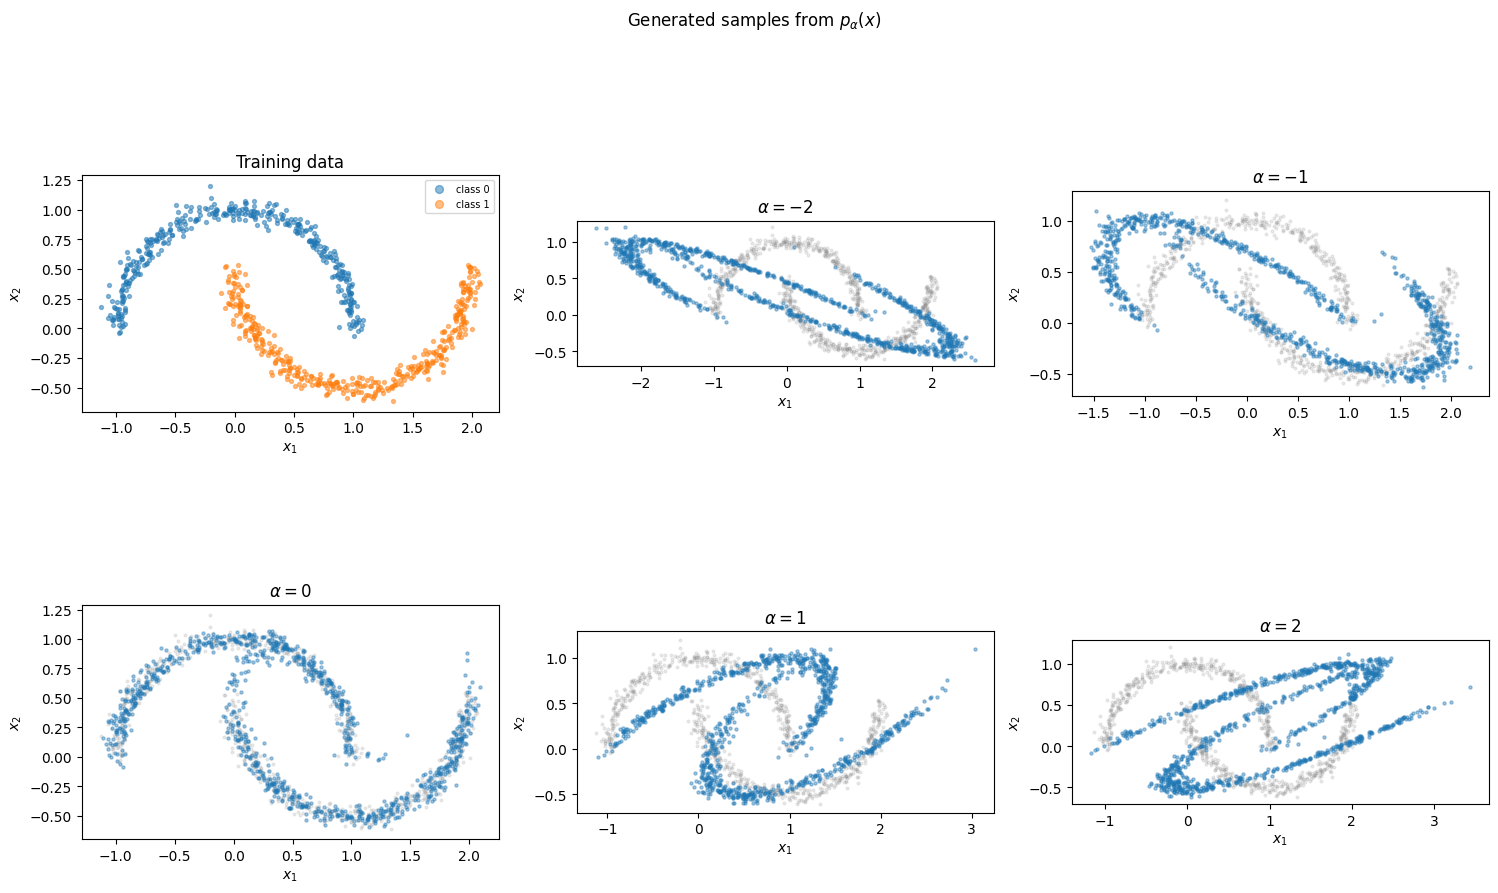

Saved figs/Figure3b.pdf


In [ ]:
fig = figure3b(samples, x_train, splits.train.labels)
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure3b.pdf")

## Q4 - Counting FLOPs

### a)

#### Assumptions/Simplifications <span style="color: red;">Add to writeup JSON</span>

- I discount the operations used to apply the mask
- I assumed the inverse affine transformations (like exp and element-wise arithmetic) are evaluated densely across all $D$ dimensions before applying masks, rather than isolating and evaluating strictly on the $D/2$ transformed dimensions.

#### Single Coupling Layer:

**Linear(D → H): computing $h_1$**

$$h_1 = \sum_{i=1}^{D} W_{1i} \cdot x_i + b_1$$

- D multiplications ($W_{1i} \cdot x_i$)
- D-1 additions (summing the products)
- 1 addition (bias)

Total: 2D FLOPs per hidden unit

Multiply by H hidden units and B batch size: $B \cdot H \cdot 2D$

**ReLU on $h_1$**

$$h_1' = \max(0, h_1)$$

- 1 FLOP

Total across all: $B \cdot H$

**Linear(H → 2D): contribution of $h_1$ to all 2D outputs**

Each of the 2D outputs needs H multiplications, H-1 additions, and 1 bias addition = 2H FLOPs per
output.

Total: $B \cdot 2D \cdot 2H$

**So the MLP cost per coupling layer is:**

$$B \cdot (2DH + H + 4DH) = B \cdot (6DH + H) = B \cdot H(6D + 1)$$

---

**$\tanh$ scaling on $s$ (Per Layer)**

All elements of $D$-dimensional $s$ have $\tanh$ applied

Total: $B \cdot 10D$

---

**Inverse Coupling Transform (Per Layer)**

Per hidden unit:

$$h_i = (h'_i - t_i) \cdot \exp(-s_i)$$

- D subtractions ($h'_i - t_i$)
- D negations ($-s_i$)
- D exponentiations ($\exp$, 10 each)
- D multiplications

Total:
$$
B \cdot (D + D + 2 + 10D) = B \cdot 13D 
$$

---

**Log Determinant (Per Layer)**

$$\log|\det J^{-1}| = -\sum_{i=1}^{D} s_i$$

- D - 1 additions (summing the s values)
- 1 negation

Total: $B \cdot D$ per coupling layer.

---

**Base Log Density**

- $20B$

---

**Final Log Prob Summation**

$$\log p(x) = \log p(z) + \sum_{k=1}^{K} \log|\det J_k^{-1}|$$

- 1 addition of $\log p(z) + \sum_{k=1}^{K}$
- $K-1$ additions in $\sum_{k=1}^{K} \log|\det J_k^{-1}|$

Total: $B \cdot K$

---

#### Grand Total

$$
N_{\text{FLOPs}} = K(BH(6D+1)+ 10BD + 13BD + BD) + 20B + BK
$$

simplifies to

$$N_{\text{FLOPs}} = BK(H(6D+1) + 24D) + B(K + 20)$$


### b)

In [ ]:
print(count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE))
# TODO: Decide which flop counter to use and justify it
params_all_ones = count_flops(dim=2, n_layers=4, hidden=128, batch_size=64)
print(f"params all one count {params_all_ones}")

10979200
params all one count 439808


In [ ]:
# FLOPs for the trained model's configuration
flops_full = count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE)
print(f"Full model (dim={N_DIM}, K={N_LAYERS}, H={N_HIDDEN}, B={BATCH_SIZE}): {flops_full:,} FLOPs")

# Demonstrate generality across different configurations
configs = [
    {"dim": 2, "n_layers": 2, "hidden": 16,  "batch_size": 128},
    {"dim": 2, "n_layers": 4, "hidden": 64,  "batch_size": 800},
    {"dim": 2, "n_layers": 8, "hidden": 128, "batch_size": 1},
    {"dim": 10, "n_layers": 8, "hidden": 128, "batch_size": 256},
]

print("\nFLOP counts for other configurations:")
print(f"{'dim':>4}  {'K':>3}  {'H':>4}  {'B':>5}  {'FLOPs':>12}")
print("-" * 36)
for cfg in configs:
    flops = count_flops(**cfg)
    print(f"{cfg['dim']:>4}  {cfg['n_layers']:>3}  {cfg['hidden']:>4}  {cfg['batch_size']:>5}  {flops:>12,}")

Full model (dim=2, K=8, H=128, B=800): 10,979,200 FLOPs

FLOP counts for other configurations:
 dim    K     H      B         FLOPs
------------------------------------
   2    2    16    128        68,352
   2    4    64    800     2,835,200
   2    8   128      1        13,724
  10    8   128    256    16,489,472
